# CWT + 2D CNN — baseline feature-representation exploration

Explores whether a Continuous Wavelet Transform (CWT) scalogram, paired with a 2D CNN (`src.CNN2D`), is a competitive feature representation next to the four already in use (raw-window 1D CNN, FFT, envelope, fault-frequency peaks).

Scope is deliberately **baseline-only**: one CNN2D model per load, trained on that load's full train split, evaluated zero-shot (no adaptation) on every other load's test split — the same protocol as Baseline 1 in `model_training.ipynb`. This answers "does CWT help at all" before investing in the full fine-tuning/CORAL adaptation matrix the other representations went through.

Uses `src/` directly (`extract_cwt`, `CNN2D`, `ScalogramDataset`, `train_cnn`, `evaluate_cnn`) rather than redefining the logic inline, since `src/` was built specifically to be reusable across notebooks and the agent.

In [1]:
import os
import pickle
import random
import time
from itertools import permutations

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from src.data_loading import label_for_item
from src.feature_extraction import extract_cwt
from src.models import CNN2D, ScalogramDataset, train_cnn
from src.evaluate import evaluate_cnn

DATA_DIR = "data"
MODELS_DIR = "models"
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


with open(os.path.join(DATA_DIR, "windows_by_load.pkl"), "rb") as f:
    windows_by_load = pickle.load(f)

LOADS = sorted(windows_by_load.keys())
print(f"Loads: {LOADS}")
for load in LOADS:
    print(f"  load={load}: train={len(windows_by_load[load]['train'])}, test={len(windows_by_load[load]['test'])} windows")

Using device: cuda
Loads: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
  load=0: train=536, test=128 windows
  load=1: train=1301, test=317 windows
  load=2: train=1326, test=322 windows
  load=3: train=1323, test=322 windows


## Precompute CWT scalograms

Compute a scalogram for every window once (rather than on the fly every training epoch) and cache it in place of the raw `window` array. `extract_cwt` benchmarked at ~20ms/window, so the full train+test set across all 4 loads (~5.6k windows) takes roughly 2 minutes.

In [2]:
def to_scalogram_items(items):
    out = []
    for item in items:
        scalogram = extract_cwt(item["window"])
        meta = {k: v for k, v in item.items() if k != "window"}
        out.append({**meta, "scalogram": scalogram})
    return out


t0 = time.time()
scalograms_by_load = {
    load: {
        "train": to_scalogram_items(windows_by_load[load]["train"]),
        "test": to_scalogram_items(windows_by_load[load]["test"]),
    }
    for load in LOADS
}
elapsed = time.time() - t0
n_total = sum(len(b["train"]) + len(b["test"]) for b in scalograms_by_load.values())
print(f"Computed {n_total} scalograms in {elapsed:.1f}s ({elapsed / n_total * 1000:.1f} ms/window)")
print(f"Scalogram shape: {scalograms_by_load[LOADS[0]]['train'][0]['scalogram'].shape}")

Computed 5575 scalograms in 119.4s (21.4 ms/window)
Scalogram shape: (32, 128)


### Sanity check: normal vs. fault scalogram

Same pair used for the time/frequency comparison plots in `data_download.ipynb` (inner race fault, 0.007in, 0hp) — a fault should show visibly more energy at the higher-frequency (lower-scale) rows than the normal signal.

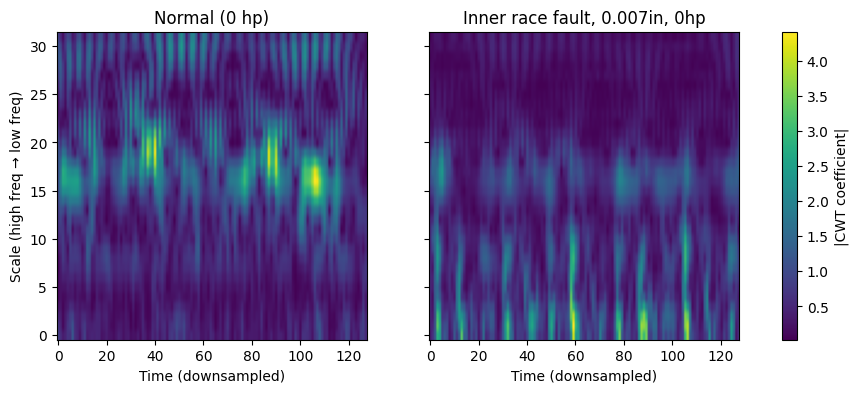

In [3]:
normal_item = next(it for it in scalograms_by_load[0]["train"] if it["category"] == "normal")
fault_item = next(
    it for it in scalograms_by_load[0]["train"]
    if it["category"] == "fault" and it["fault_location"] == "inner_race" and it["fault_diameter_in"] == 0.007
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, item, title in zip(axes, [normal_item, fault_item], ["Normal (0 hp)", "Inner race fault, 0.007in, 0hp"]):
    im = ax.imshow(item["scalogram"], aspect="auto", origin="lower", cmap="viridis")
    ax.set_title(title)
    ax.set_xlabel("Time (downsampled)")
fig.colorbar(im, ax=axes, label="|CWT coefficient|")
axes[0].set_ylabel("Scale (high freq \u2192 low freq)")
plt.show()

## Train one baseline CNN2D per load

Same recipe as Baseline 1 (`model_training.ipynb`): full train split, all-parameters training, no adaptation. Uses `src.train_cnn` with `dataset_cls=ScalogramDataset`.

In [4]:
os.makedirs(MODELS_DIR, exist_ok=True)
cwt_models = {}

for load in LOADS:
    set_seed(SEED)
    model = CNN2D()
    t0 = time.time()
    train_cnn(model, scalograms_by_load[load]["train"], device=DEVICE, dataset_cls=ScalogramDataset)
    cwt_models[load] = model
    torch.save(model.state_dict(), os.path.join(MODELS_DIR, f"cwt_baseline1_full_load{load}.pt"))
    print(f"load={load}: trained on {len(scalograms_by_load[load]['train'])} windows in {time.time() - t0:.1f}s")

print(f"Saved {len(LOADS)} checkpoints to {MODELS_DIR}/")

load=0: trained on 536 windows in 4.4s


load=1: trained on 1301 windows in 5.8s


load=2: trained on 1326 windows in 5.6s


load=3: trained on 1323 windows in 7.8s
Saved 4 checkpoints to models/


## Zero-shot cross-domain evaluation

Evaluate every source model against every other load's held-out test split — all 12 ordered pairs, matching the existing `baseline_results.csv` protocol.

In [5]:
results = []
for source_load, target_load in permutations(LOADS, 2):
    eval_result = evaluate_cnn(
        cwt_models[source_load], scalograms_by_load[target_load]["test"], device=DEVICE, dataset_cls=ScalogramDataset
    )
    results.append({
        "source_load": source_load,
        "target_load": target_load,
        "cwt_baseline1_acc": eval_result["accuracy"],
        "cwt_baseline1_f1": eval_result["macro_f1"],
    })
    print(f"{source_load}->{target_load}: acc={eval_result['accuracy']:.3f} f1={eval_result['macro_f1']:.3f}")

cwt_results_df = pd.DataFrame(results)
results_path = os.path.join(DATA_DIR, "cwt_baseline_results.csv")
cwt_results_df.to_csv(results_path, index=False)
print(f"\nSaved to {results_path}")
cwt_results_df

0->1: acc=0.568 f1=0.438


0->2: acc=0.587 f1=0.513
0->3: acc=0.457 f1=0.351


1->0: acc=0.703 f1=0.553
1->2: acc=0.966 f1=0.961


1->3: acc=0.780 f1=0.656
2->0: acc=0.641 f1=0.493
2->1: acc=0.918 f1=0.878
2->3: acc=0.736 f1=0.629


3->0: acc=0.492 f1=0.283
3->1: acc=0.672 f1=0.562
3->2: acc=0.783 f1=0.717

Saved to data/cwt_baseline_results.csv


,source_load,target_load,cwt_baseline1_acc,cwt_baseline1_f1
0,0,1,0.567823,0.437504
1,0,2,0.586957,0.512886
2,0,3,0.456522,0.351135
3,1,0,0.703125,0.552952
4,1,2,0.965839,0.960964
5,1,3,0.779503,0.655680
6,2,0,0.640625,0.493397
7,2,1,0.917981,0.878294
8,2,3,0.736025,0.628965
9,3,0,0.492188,0.283287


## Compare against the existing feature representations

Mean accuracy across all 12 pairs, next to Baseline 1 (raw-window 1D CNN) and the three RF-no-adapt representations — all zero-shot, no-adaptation methods, so directly comparable to `cwt_baseline1_acc`.

In [6]:
policy_table = pd.read_csv(os.path.join(DATA_DIR, "agent_policy_table.csv"))

comparison = pd.DataFrame({
    "CWT + 2D CNN (baseline, no adapt)": [cwt_results_df["cwt_baseline1_acc"].mean()],
    "Baseline1 raw-window 1D CNN (no adapt)": [policy_table["Baseline1 (no adapt)"].mean()],
    "RF no-adapt (fft)": [policy_table["RF no-adapt (fft)"].mean()],
    "RF no-adapt (envelope)": [policy_table["RF no-adapt (envelope)"].mean()],
    "RF no-adapt (fault_freq)": [policy_table["RF no-adapt (fault_freq)"].mean()],
}).T
comparison.columns = ["mean_accuracy_12_pairs"]
comparison.sort_values("mean_accuracy_12_pairs", ascending=False)

,mean_accuracy_12_pairs
RF no-adapt (fft),0.785051
RF no-adapt (envelope),0.709373
Baseline1 raw-window 1D CNN (no adapt),0.696602
"CWT + 2D CNN (baseline, no adapt)",0.691760
RF no-adapt (fault_freq),0.631223
